In [47]:
import pandas as pd
import requests
import csv
import duckdb
import datetime
from pathlib import Path
from dateutil.relativedelta import relativedelta
import itertools
import json

df = pd.read_csv('data/time_data.csv')
df['settlementDate'] = pd.to_datetime(df['settlementDate'])
df['timeFrom'] = pd.to_datetime(df['timeFrom'])
df['timeTo'] = pd.to_datetime(df['timeTo'])
print(df.dtypes)
df.head()

action                           str
fuelType                         str
leadPartyName                    str
gspGroupId                       str
demandCapacity               float64
generationCapacity           float64
BmUnitId                         str
settlementDate        datetime64[us]
settlementPeriod               int64
timeFrom              datetime64[us]
timeTo                datetime64[us]
expected_mwh                 float64
actual_mwh                   float64
change_in_mwh                float64
change_cost                  float64
longitude                    float64
latitude                     float64
dtype: object


,action,fuelType,leadPartyName,gspGroupId,demandCapacity,generationCapacity,BmUnitId,settlementDate,settlementPeriod,timeFrom,timeTo,expected_mwh,actual_mwh,change_in_mwh,change_cost,longitude,latitude
0,Wind curtailed,WIND,Aberdeen Offshore Wind Farm,NaN,-2.0,99.0,ABRBO-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,18.75,18.75,0.0,0.0,-1.972800,57.222600
1,Wind curtailed,WIND,Npower Commercial Gas Limited,_N,-10.0,36.0,ABRTW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,13.50,13.10,0.4,36.4,-3.988675,55.621764
2,Wind curtailed,WIND,Mobius Renewables Gen. (GB2,NaN,-2.0,42.6,ACHRW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,21.50,21.50,0.0,0.0,-5.393722,56.342860
3,Wind curtailed,WIND,Afton Wind Farm Limited,NaN,-2.0,50.0,AFTOW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,17.50,17.50,0.0,0.0,-4.169100,55.312800
4,Wind curtailed,WIND,ENGIE Power Limited,_N,0.0,38.0,AIRSW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,9.00,9.00,0.0,0.0,-4.713441,54.970896


In [48]:
print(f"Total Expected Wind Generation: {df[df['action'] == 'Wind curtailed']['expected_mwh'].sum()/1000:.2f} GWh")
print(f"Total Actual Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['actual_mwh'].sum()/1000:.2f} GWh")
print(f"Total Other ramp up Generation (GWh): {df[df['action'] == 'Other ramped up']['change_in_mwh'].sum()/1000:.2f} GWh")
print(f"Total Curtailed Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['change_in_mwh'].sum()/1000:.2f} GWh")
print(f"Total Cost of Other ramped up (£M): £{df[df['action'] == 'Other ramped up']['change_cost'].sum()/1000000:.2f} million")
print(f"Total Cost of Wind Curtailment (£M): £{df[df['action'] == 'Wind curtailed']['change_cost'].sum()/1000000:.2f} million")

Total Expected Wind Generation: 81422.83 GWh
Total Actual Wind Generation (GWh): 71105.10 GWh
Total Other ramp up Generation (GWh): 0.00 GWh
Total Curtailed Wind Generation (GWh): 10317.74 GWh
Total Cost of Other ramped up (£M): £0.00 million
Total Cost of Wind Curtailment (£M): £401.50 million


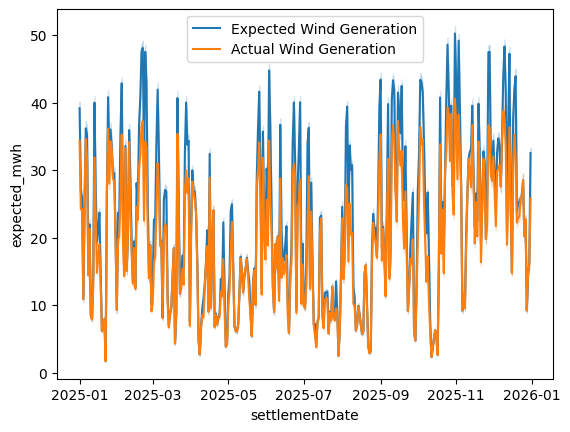

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

df['dayofyear'] = df['timeFrom'].dt.day_of_year

wind_df = df[df['action'] == 'Wind curtailed']

ax = sns.lineplot(data=wind_df, x='settlementDate',y='expected_mwh', label='Expected Wind Generation')
ax = sns.lineplot(data=wind_df, x='settlementDate',y='actual_mwh', label='Actual Wind Generation')

ax.legend()
plt.show()

In [69]:
import math

wind_df = df[df['action'] == 'Wind curtailed'].sort_values(['settlementDate','settlementPeriod'])

train_cutoff = '2025-10-01'
test_cutoff = '2025-10-15'

train = wind_df[wind_df['settlementDate'] < train_cutoff]
test = wind_df[wind_df['settlementDate'] >= test_cutoff]

def create_features(df, cols, intervals):
    df = df.copy()
    for col in cols:
        for interval in intervals:
            shifted = df.groupby('BmUnitId')[col].shift(interval)
            df[f'{col}_lag{interval}'] = shifted
            df[f'{col}_lag{interval}_roll{interval}'] = shifted.groupby(df['BmUnitId']).rolling(interval).mean().reset_index(level=0,drop=True)

    df['dayofyear_x'] = df['dayofyear'].apply(lambda x: math.sin(2*math.pi*x/365))
    df['dayofyear_y'] = df['dayofyear'].apply(lambda x: math.cos(2*math.pi*x/365))
    
    df['dayofweek'] = df['settlementDate'].dt.day_of_week
    df['dayofweek_x'] = df['dayofweek'].apply(lambda x: math.sin(2*math.pi*x/7))
    df['dayofweek_y'] = df['dayofweek'].apply(lambda x: math.cos(2*math.pi*x/7))
    
    return df

lag_cols = ['expected_mwh','actual_mwh','change_in_mwh','change_cost']
intervals = [3,4,5,6,12,24,48]

X_train = create_features(train, lag_cols, intervals)
X_test = create_features(test, lag_cols, intervals)

X_train.head()

,action,fuelType,leadPartyName,gspGroupId,demandCapacity,generationCapacity,BmUnitId,settlementDate,settlementPeriod,timeFrom,...,change_cost_lag12_roll12,change_cost_lag24,change_cost_lag24_roll24,change_cost_lag48,change_cost_lag48_roll48,dayofyear_x,dayofyear_y,dayofweek,dayofweek_x,dayofweek_y
0,Wind curtailed,WIND,Aberdeen Offshore Wind Farm,NaN,-2.0,99.0,ABRBO-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
1,Wind curtailed,WIND,Npower Commercial Gas Limited,_N,-10.0,36.0,ABRTW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
2,Wind curtailed,WIND,Mobius Renewables Gen. (GB2,NaN,-2.0,42.6,ACHRW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
3,Wind curtailed,WIND,Afton Wind Farm Limited,NaN,-2.0,50.0,AFTOW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521
4,Wind curtailed,WIND,ENGIE Power Limited,_N,0.0,38.0,AIRSW-1,2025-01-01,1,2025-01-01,...,NaN,NaN,NaN,NaN,NaN,0.017213,0.999852,2,0.974928,-0.222521


In [70]:
drop_cols = ['action','fuelType','timeFrom','timeTo','settlementDate']
drop_cols.append('gspGroupId')
for col in lag_cols:
    drop_cols.append(col)

X_train = X_train[X_train['change_cost'] > 0].dropna()
X_test = X_test[X_test['change_cost'] > 0].dropna()

Y_h1_train = X_train.groupby('BmUnitId').shift(-1)['change_cost']

X_train = X_train[Y_h1_train.notna()]
Y_h1_train = Y_h1_train[Y_h1_train.notna()]


Y_h1_test = X_test.groupby('BmUnitId').shift(-1)['change_cost']

X_test = X_test[Y_h1_test.notna()]
Y_h1_test = Y_h1_test[Y_h1_test.notna()]


X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

print(Y_h1_train.isna().sum())
print(len(Y_h1_train))
print(len(X_train))


0
21049
21049


In [71]:
print(X_train.dtypes)

leadPartyName             str
demandCapacity        float64
generationCapacity    float64
BmUnitId                  str
settlementPeriod        int64
                       ...   
dayofyear_x           float64
dayofyear_y           float64
dayofweek               int32
dayofweek_x           float64
dayofweek_y           float64
Length: 69, dtype: object


In [52]:
train_min = X_train['dayofyear'].min()
train_max = X_train['dayofyear'].max()
test_min = X_test['dayofyear'].min()
test_max = X_test['dayofyear'].max()

print(f'Training set day range: {train_min} to {train_max}')
print(f'Test set day range: {test_min} to {test_max}')

Training set day range: 3 to 270
Test set day range: 292 to 365


In [53]:
import lightgbm as lgb
import numpy as np

categorical_features = ['BmUnitId', 'leadPartyName']

lgbm_model_h1 = lgb.LGBMRegressor()

lgbm_xtrain = X_train.copy()
for cat in categorical_features:
    lgbm_xtrain[cat] = lgbm_xtrain[cat].astype('category')

lgbm_xtest = X_test.copy()
for cat in categorical_features:
    lgbm_xtest[cat] = lgbm_xtest[cat].astype('category')

lgbm_model_h1.fit(lgbm_xtrain,Y_h1_train,categorical_feature=categorical_features)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14260
[LightGBM] [Info] Number of data points in the train set: 21049, number of used features: 69
[LightGBM] [Info] Start training from score 1115.998953


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [54]:
from sklearn.metrics import root_mean_squared_error

predictions_h1 = lgbm_model_h1.predict(lgbm_xtest)

mask = Y_h1_test.notna()
Y_h1_test_clean = Y_h1_test[mask]
predictions_h1_clean = predictions_h1[mask]



error_h1 = root_mean_squared_error(Y_h1_test_clean,predictions_h1_clean)
print(Y_h1_test.describe())
print(f'RMS error between actual vs prediction: {error_h1}')

count    6480.000000
mean     1021.706292
std       674.424388
min         1.062500
25%       469.250000
50%      1013.160000
75%      1360.000000
max      4698.773333
Name: change_cost, dtype: float64
RMS error between actual vs prediction: 384.8069858467966


In [55]:
predictions_h2 = lgbm_model_h1.predict(lgbm_xtest)

mask = Y_h1_test.notna()
Y_h1_test_clean = Y_h1_test[mask]
predictions_h1_clean = predictions_h1[mask]



error_h1 = root_mean_squared_error(Y_h1_test_clean,predictions_h1_clean)
print(Y_h1_test.describe())
print(f'RMS error between actual vs prediction: {error_h1}')

count    6480.000000
mean     1021.706292
std       674.424388
min         1.062500
25%       469.250000
50%      1013.160000
75%      1360.000000
max      4698.773333
Name: change_cost, dtype: float64
RMS error between actual vs prediction: 384.8069858467966


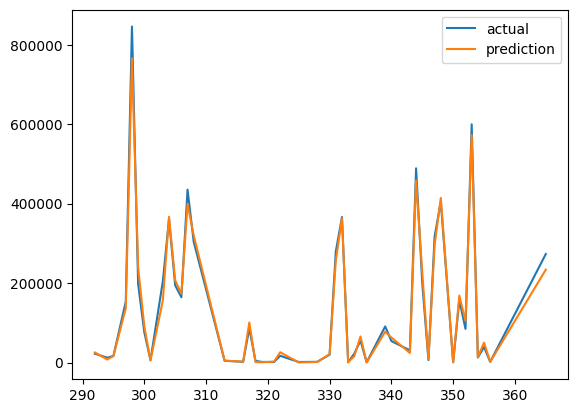

In [56]:
X_test_final = X_test.copy()
X_test_final['1day_actual'] = Y_h1_test
X_test_final['1day_prediction'] = predictions_h1

test_daily = X_test_final.groupby('dayofyear')[['1day_actual','1day_prediction']].sum().reset_index()


plt.plot(test_daily['dayofyear'], test_daily['1day_actual'], label='actual')
plt.plot(test_daily['dayofyear'], test_daily['1day_prediction'], label='prediction')
plt.legend()
plt.show()

In [57]:
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

lgbm_models = {}

for quantile in quantiles:
    model = lgb.LGBMRegressor(objective='quantile',alpha=quantile)
    model.fit(lgbm_xtrain,Y_h1_train)
    lgbm_models[quantile] = model

lgbm_quantile_predictions = {}

for alpha, model in lgbm_models.items():
    prediction = model.predict(lgbm_xtest,categorical_feature=categorical_features)
    lgbm_quantile_predictions[alpha] = prediction

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001958 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14260
[LightGBM] [Info] Number of data points in the train set: 21049, number of used features: 69
[LightGBM] [Info] Start training from score 124.785004
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14260
[LightGBM] [Info] Number of data points in the train set: 21049, number of used features: 69
[LightGBM] [Info] Start training from score 369.135010
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14260
[LightGBM] [Info] Number of data points in the train set: 21049, number of used features: 69
[LightGBM] [Info] St

<Axes: xlabel='settlementDate'>

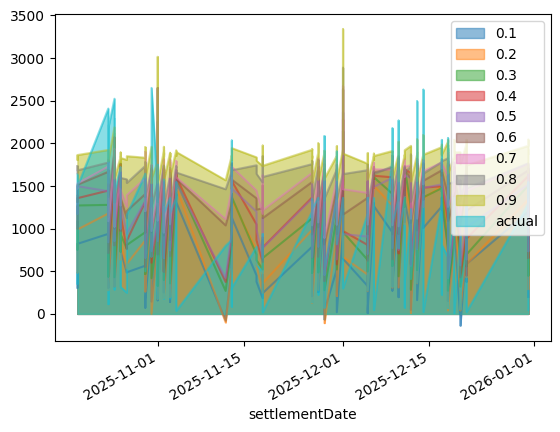

In [58]:
lgbm_quantile_df = pd.DataFrame(lgbm_quantile_predictions, index=X_test.index).dropna()
lgbm_quantile_df['actual'] = Y_h1_test
lgbm_quantile_df['settlementDate'] = wind_df['settlementDate']
lgbm_quantile_df['BmUnitId'] = X_test['BmUnitId']

lgbm_quantile_df[(lgbm_quantile_df['BmUnitId'] == 'TMNCW-1')].plot.area(x='settlementDate', stacked=False)

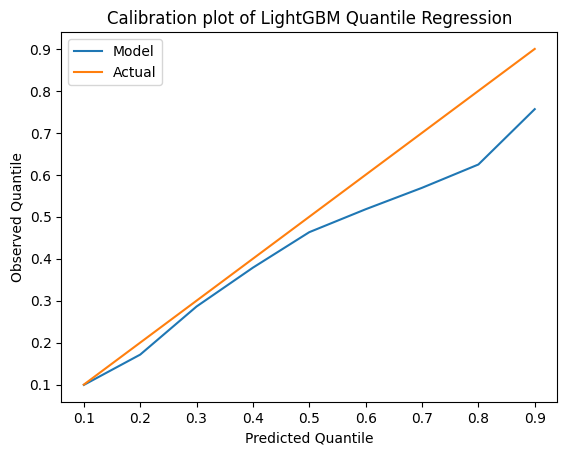

In [59]:
lgbm_actual_coverage = {}
for quantile in quantiles:
    model_quantile = float((lgbm_quantile_df['actual'] <= lgbm_quantile_df[quantile]).mean())
    lgbm_actual_coverage[quantile] = model_quantile

plt.plot(lgbm_actual_coverage.keys(), list(lgbm_actual_coverage.values()), label='Model')
plt.plot(quantiles, list(lgbm_actual_coverage.keys()), label='Actual')
plt.legend()
plt.xlabel('Predicted Quantile')
plt.ylabel('Observed Quantile')
plt.title('Calibration plot of LightGBM Quantile Regression')
plt.show()


In [60]:
import xgboost as xgb

xgb_models = {}

xgb_xtrain = X_train.copy()
xgb_xtest = X_test.copy()

for cat in categorical_features:
    xgb_xtrain[cat] = xgb_xtrain[cat].astype('category')
    xgb_xtrain[cat] = xgb_xtrain[cat].cat.codes

    xgb_xtest[cat] = xgb_xtest[cat].astype('category')
    xgb_xtest[cat] = xgb_xtest[cat].cat.codes

print(xgb_xtrain.dtypes.value_counts())
print(Y_h1_train.isna().sum())

for q in quantiles:
    model = xgb.XGBRegressor(objective='reg:quantileerror',quantile_alpha=q,enable_categorical=True)
    model.fit(xgb_xtrain,Y_h1_train)
    xgb_models[q] = model


float64    64
int8        2
int32       2
int64       1
Name: count, dtype: int64
0


<Axes: xlabel='settlementDate'>

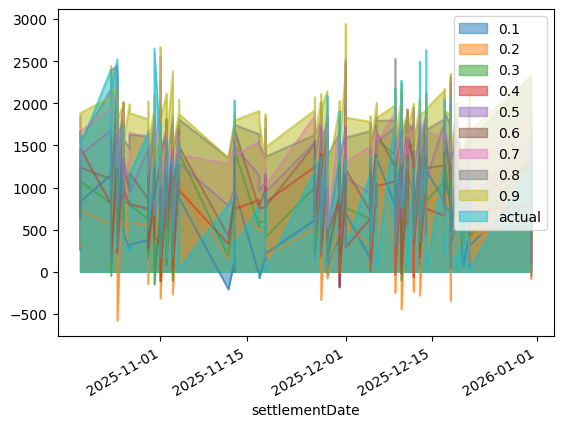

In [61]:
xgb_quantile_predictions = {}

for quantile, model in xgb_models.items():
    prediction = model.predict(xgb_xtest)
    xgb_quantile_predictions[quantile] = prediction

xgb_quantile_df = pd.DataFrame(xgb_quantile_predictions, index=X_test.index).dropna()
xgb_quantile_df['actual'] = Y_h1_test
xgb_quantile_df['settlementDate'] = wind_df['settlementDate']
xgb_quantile_df['BmUnitId'] = X_test['BmUnitId']

xgb_quantile_df[(xgb_quantile_df['BmUnitId'] == 'TMNCW-1')].plot.area(x='settlementDate', stacked=False)


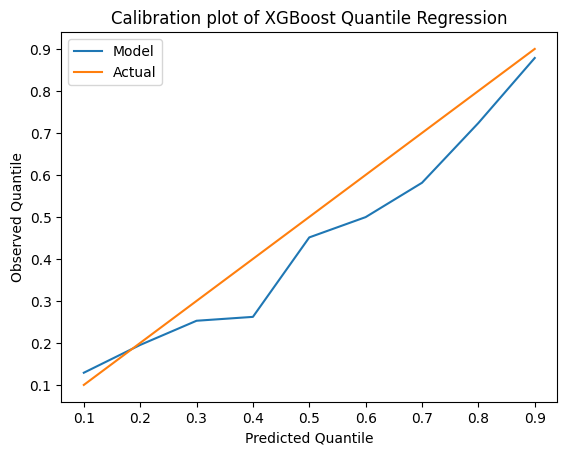

In [62]:
xgb_actual_coverage = {}
for quantile in quantiles:
    model_quantile = float((xgb_quantile_df['actual'] <= xgb_quantile_df[quantile]).mean())
    xgb_actual_coverage[quantile] = model_quantile

plt.plot(xgb_actual_coverage.keys(), list(xgb_actual_coverage.values()), label='Model')
plt.plot(quantiles, list(xgb_actual_coverage.keys()), label='Actual')
plt.legend()
plt.xlabel('Predicted Quantile')
plt.ylabel('Observed Quantile')
plt.title('Calibration plot of XGBoost Quantile Regression')
plt.show()


<Axes: >

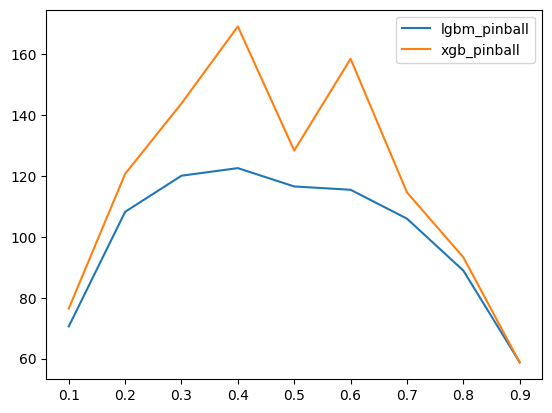

In [63]:
from sklearn.metrics import mean_pinball_loss

lgbm_plosses = {}
xgb_plosses = {}

for q, p in lgbm_quantile_predictions.items():
    lgbm_plosses[q] = mean_pinball_loss(Y_h1_test,p,alpha=q)

for q, p in xgb_quantile_predictions.items():
    xgb_plosses[q] = mean_pinball_loss(Y_h1_test,p,alpha=q)

pinball_losses_df = pd.DataFrame({'lgbm_pinball':lgbm_plosses, 'xgb_pinball':xgb_plosses})
pinball_losses_df.plot()

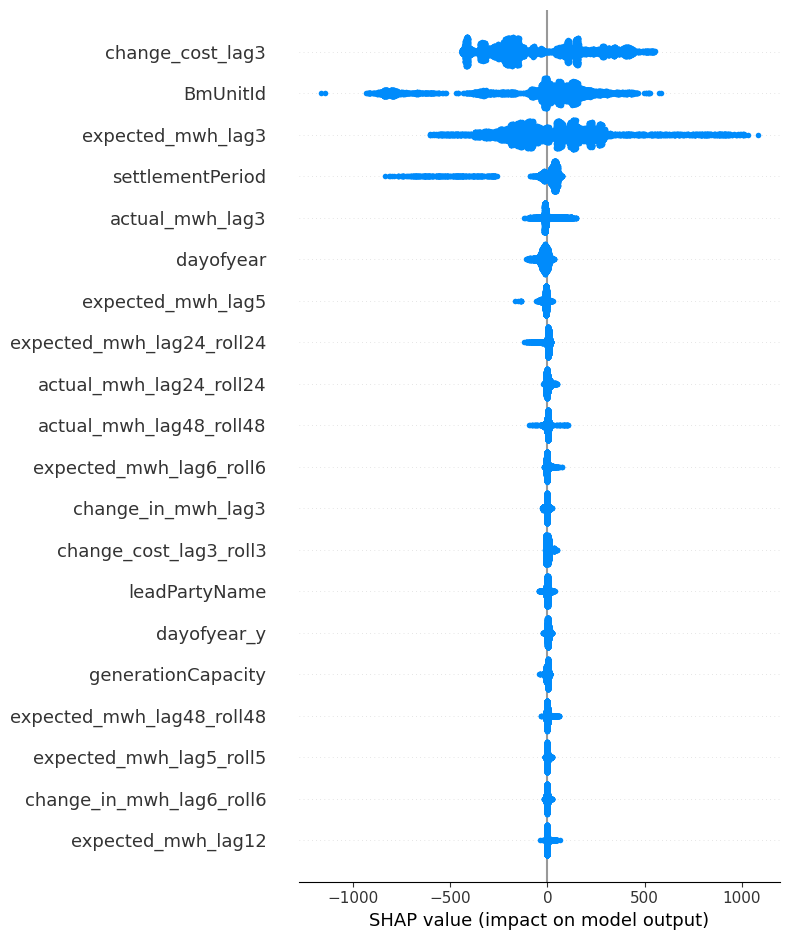

In [72]:
import numpy
import shap

explainer = shap.TreeExplainer(lgbm_models[0.5])
shap_values_lgbm = explainer.shap_values(lgbm_xtest)
shap.summary_plot(shap_values=shap_values_lgbm, feature_names = lgbm_xtest.columns.tolist())

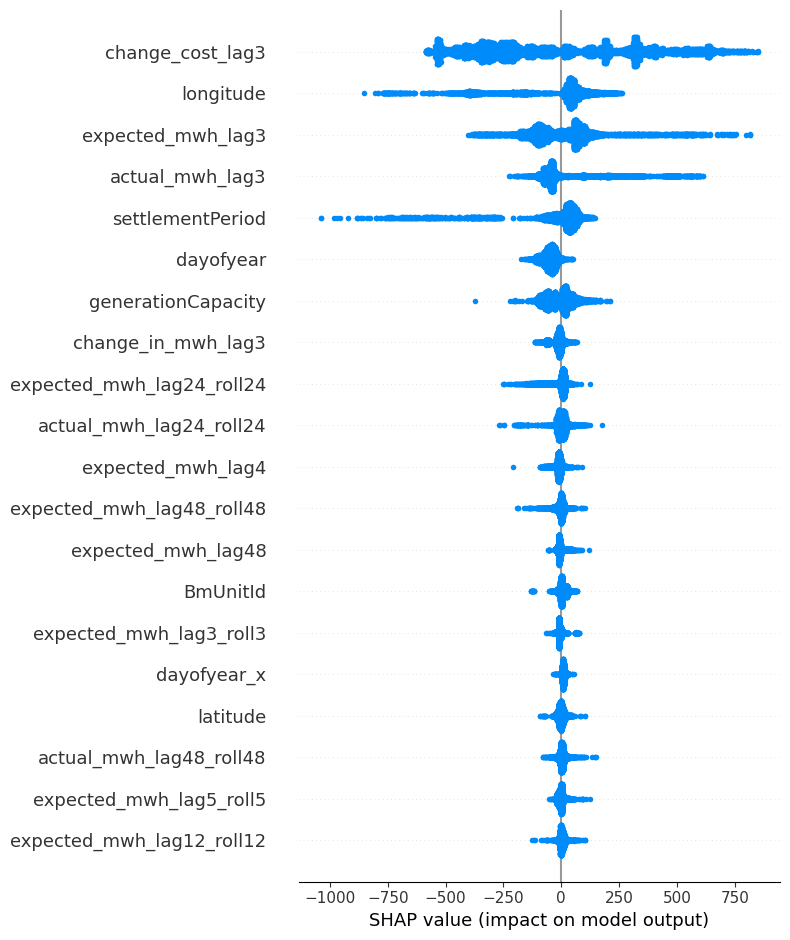

In [73]:
explainer = shap.TreeExplainer(xgb_models[0.5])
shap_values_xgb = explainer.shap_values(xgb_xtest)
shap.summary_plot(shap_values=shap_values_xgb, feature_names = xgb_xtest.columns.tolist())

In [93]:
def prepare_data(df, lag_cols, lag_intervals):
    df = df.copy()
    for col in lag_cols:
        for interval in lag_intervals:
            shifted = df.groupby('BmUnitId')[col].shift(interval)
            df[f'{col}_lag{interval}'] = shifted
            df[f'{col}_lag{interval}_roll{interval}'] = shifted.groupby(df['BmUnitId']).rolling(interval).mean().reset_index(level=0,drop=True)

    df['dayofyear_x'] = df['dayofyear'].apply(lambda x: math.sin(2*math.pi*x/365))
    df['dayofyear_y'] = df['dayofyear'].apply(lambda x: math.cos(2*math.pi*x/365))
    
    df['dayofweek'] = df['settlementDate'].dt.day_of_week
    df['dayofweek_x'] = df['dayofweek'].apply(lambda x: math.sin(2*math.pi*x/7))
    df['dayofweek_y'] = df['dayofweek'].apply(lambda x: math.cos(2*math.pi*x/7))

    categorical_cols = df.select_dtypes(include=['object','str'])

    for col in categorical_cols:
        df[col] = df[col].astype('category')
    
    drop_cols = ['action','fuelType','timeFrom','timeTo','settlementDate']
    drop_cols.append('gspGroupId')
    for col in lag_cols:
        drop_cols.append(col)
    
    Y = df.groupby('BmUnitId').shift(-1)['change_cost']
    valid = df.drop(columns=drop_cols, errors='ignore').notna().all(axis=1) & Y.notna()
    X = df.drop(columns=drop_cols, errors='ignore')[valid]
    Y = Y[valid]

    return X, Y


def create_folds(df,cutoffs):
    folds = {}
    start = '2025-01-01'
    for i, cutoff in enumerate(cutoffs):
        fold = {}
        train = df[(df['settlementDate'] >= start) & (df['settlementDate'] < cutoff)]
        test = df[(df['settlementDate'] > cutoff)]
        X_train, Y_train = prepare_data(train, lag_cols, intervals)
        fold['X_train'] = X_train
        fold['Y_train'] = Y_train
        X_test, Y_test = prepare_data(test, lag_cols, intervals)
        fold['X_test'] = X_test
        fold['Y_test'] = Y_test
        folds[i] = fold
    return folds


In [95]:
cutoffs = ['2025-04-01', '2025-07-01', '2025-10-01']

folds = create_folds(wind_df, cutoffs)



for num, fold in folds.items():
    model = lgb.LGBMRegressor()
    fold['model'] = model.fit(fold['X_train'],fold['Y_train'])
    fold['Y_pred'] = model.predict(fold['X_test'])
    fold['rmse'] = root_mean_squared_error(fold['Y_test'],fold['Y_pred'])
    fold['mae'] = np.mean(np.abs(fold['Y_test']-fold['Y_pred']))

for i, fold in folds.items():
    print(f"Fold {i}: RMSE={fold['rmse']:.2f}, MAE={fold['mae']:.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15417
[LightGBM] [Info] Number of data points in the train set: 878272, number of used features: 69
[LightGBM] [Info] Start training from score 77.575563
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15696
[LightGBM] [Info] Number of data points in the train set: 1788688, number of used features: 69
[LightGBM] [Info] Start training from score 83.663814
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no